<a href="https://www.kaggle.com/code/hbad0612/eda-clinical-data-for-alzheimers?scriptVersionId=346643317" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/legendahmed/alzheimers-clinical-data/clinical-data-for Alzheimers.csv


1. Open dataset:

In [2]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/legendahmed/alzheimers-clinical-data/clinical-data-for Alzheimers.csv')
print('First 5 rows:')
print(df.head(5),'\n')
print('Last 5 rows:')
print(df.tail(5))

First 5 rows:
    Subject  Gender mmse  ageAtEntry  cdr memory            dx1
0  OAS30124  female   16    79.14579  1.0      1  'AD Dementia'
1  OAS30124  female   21    79.14579  0.5    0.5  'AD Dementia'
2  OAS31129  female   20    68.07666  1.0      1  'AD Dementia'
3  OAS31129  female   28    68.07666  1.0      1  'AD Dementia'
4  OAS31129  female   29    68.07666  0.5    0.5  'AD Dementia' 

Last 5 rows:
       Subject  Gender mmse  ageAtEntry  cdr memory                   dx1
1224  OAS30397    male   22    68.90075  1.0      1         'AD Dementia'
1225  OAS30397    male   16    68.90075  1.0      1         'AD Dementia'
1226  OAS30886    male   28    67.77276  0.5    0.5         'AD Dementia'
1227  OAS30954  female   17    80.06844  1.0      1         'AD Dementia'
1228  OAS30016    male   26    76.96646  0.5      1  'uncertain dementia'


2. Explore Data Analysis:

In [4]:
print('Data shape:',df.shape)
print(df.info(memory_usage='deep'))

Data shape: (1229, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject     1229 non-null   object 
 1   Gender      1229 non-null   object 
 2   mmse        1229 non-null   object 
 3   ageAtEntry  1229 non-null   float64
 4   cdr         1229 non-null   float64
 5   memory      1229 non-null   object 
 6   dx1         1229 non-null   object 
dtypes: float64(2), object(5)
memory usage: 351.8 KB
None


In [5]:
# missing values
df.isna().sum()

Subject       0
Gender        0
mmse          0
ageAtEntry    0
cdr           0
memory        0
dx1           0
dtype: int64

In [6]:
# Gender distribution
gender = df['Gender'].value_counts()
gender_pct = (gender/len(df['Gender'])*100).round(2)
gender_df = pd.DataFrame({'count': gender, 'pct': gender_pct})
print(gender_df)

        count    pct
Gender              
male      692  56.31
female    537  43.69


In [7]:
# Diagnose status
dx1_count = df['dx1'].value_counts()
dx1_pct = (dx1_count/len(df['dx1'])*100).round(2)
dx1_df = pd.DataFrame({'count': dx1_count, 'pct': dx1_pct})
print(dx1_df)

                      count    pct
dx1                               
'AD Dementia'           846  68.84
'uncertain dementia'    366  29.78
'No dementia'            17   1.38


Subject
OAS30923    15
OAS30156    14
OAS30119    10
OAS30214    10
OAS30322    10
            ..
OAS30477     1
OAS30518     1
OAS30795     1
OAS30809     1
OAS30217     1
Name: count, Length: 426, dtype: int64


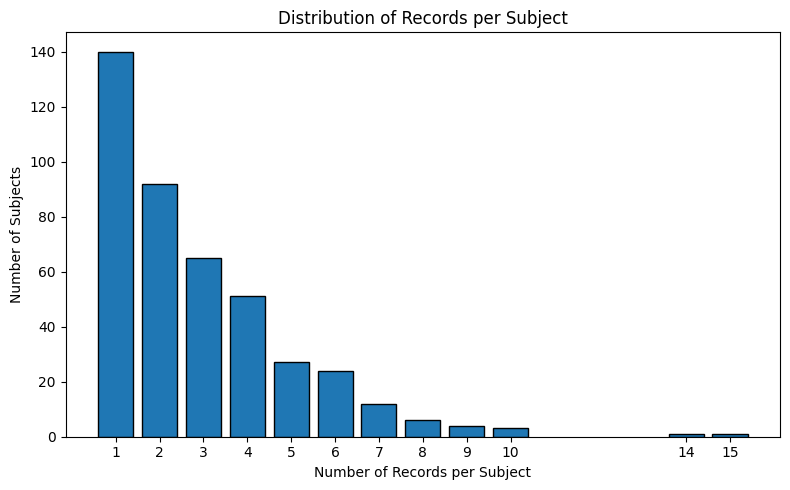

In [8]:
# Count subject visit
sub_count = df['Subject'].value_counts()
print(sub_count)

# Count how many subjects have 1, 2, 3, ... records
record_distribution = sub_count.value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    record_distribution.index,
    record_distribution.values,
    edgecolor='black'
)

plt.xlabel('Number of Records per Subject')
plt.ylabel('Number of Subjects')
plt.title('Distribution of Records per Subject')

plt.xticks(record_distribution.index)

plt.tight_layout()
plt.show()

In [9]:
print(sub_count.describe())

count    426.000000
mean       2.884977
std        2.125124
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       15.000000
Name: count, dtype: float64


In [10]:
# Count unique subjects
sub_unique = df['Subject'].nunique()
print('Total unique subject:',sub_unique, 'subjects')
print('Average records per subject:', len(df) / sub_unique)

Total unique subject: 426 subjects
Average records per subject: 2.884976525821596


In [11]:
# Inspect mmse and memory because they are defined as object type
print(df['mmse'].unique())
print(df['memory'].unique())

['16' '21' '20' '28' '29' '24' '30' '23' '25' '27' '17' '26' '1' '19' '?'
 '22' '10' '15' '18' '13' '12' '2' '14' '7' '6' '4' '9' '0']
['1' '0.5' '2' '0' '3' '?']


In [12]:
# Replace '?' with missing value
df[['mmse', 'memory']] = df[['mmse', 'memory']].replace('?', np.nan)

# Convert to numeric
df['mmse'] = pd.to_numeric(df['mmse'])
df['memory'] = pd.to_numeric(df['memory'])

# Check
print(df[['mmse', 'memory']].dtypes)

mmse      float64
memory    float64
dtype: object


In [13]:
# Descriptive statistics
df[['mmse', 'ageAtEntry', 'cdr', 'memory']].describe()

,mmse,ageAtEntry,cdr,memory
count,1201.000000,1229.000000,1229.000000,1228.000000
mean,25.343047,72.900069,0.702604,0.786645
std,4.390773,7.739166,0.415548,0.494551
min,0.000000,47.605750,0.000000,0.000000
25%,23.000000,67.550995,0.500000,0.500000
50%,26.000000,73.013010,0.500000,0.500000
75%,29.000000,78.650240,1.000000,1.000000
max,30.000000,95.567420,3.000000,3.000000


In [14]:
for col in ['mmse', 'ageAtEntry', 'cdr', 'memory']:
    print(
        col,
        "min =", df[col].min(),
        "max =", df[col].max(),
        "unique =", df[col].nunique()
    )

mmse min = 0.0 max = 30.0 unique = 27
ageAtEntry min = 47.60575 max = 95.56742 unique = 416
cdr min = 0.0 max = 3.0 unique = 5
memory min = 0.0 max = 3.0 unique = 5


In [17]:
na_mmse = df[df['mmse'].between(0, 30) == False]
na_mmse

,Subject,Gender,mmse,ageAtEntry,cdr,memory,dx1
69,OAS30805,male,NaN,66.592740,0.5,1.0,'AD Dementia'
74,OAS30805,male,NaN,66.592740,0.5,0.5,'AD Dementia'
96,OAS30650,female,NaN,75.479805,1.0,2.0,'AD Dementia'
118,OAS30314,female,NaN,56.561260,0.5,0.5,'uncertain dementia'
120,OAS30314,female,NaN,56.561260,0.5,0.5,'uncertain dementia'
123,OAS30314,female,NaN,56.561260,0.5,0.5,'uncertain dementia'
125,OAS30420,female,NaN,85.330600,0.5,0.5,'AD Dementia'
156,OAS30675,male,NaN,68.958244,0.5,0.5,'uncertain dementia'
267,OAS30505,male,NaN,67.852160,0.5,0.5,'uncertain dementia'
276,OAS30700,female,NaN,79.542780,0.5,0.0,'uncertain dementia'


In [24]:
na_cdr = df[df['cdr'].between(0.0, 3.0) == False]
na_cdr

,Subject,Gender,mmse,ageAtEntry,cdr,memory,dx1


In [22]:
na_memory = df[df['memory'].between(0.0, 3.0) == False]
na_memory

,Subject,Gender,mmse,ageAtEntry,cdr,memory,dx1
548,OAS31109,female,24.0,68.8,2.0,NaN,'AD Dementia'


In [27]:
# Drop all NaN values and store in df1
df1 = df.dropna()
df1

,Subject,Gender,mmse,ageAtEntry,cdr,memory,dx1
0,OAS30124,female,16.0,79.14579,1.0,1.0,'AD Dementia'
1,OAS30124,female,21.0,79.14579,0.5,0.5,'AD Dementia'
2,OAS31129,female,20.0,68.07666,1.0,1.0,'AD Dementia'
3,OAS31129,female,28.0,68.07666,1.0,1.0,'AD Dementia'
4,OAS31129,female,29.0,68.07666,0.5,0.5,'AD Dementia'
...,...,...,...,...,...,...,...
1224,OAS30397,male,22.0,68.90075,1.0,1.0,'AD Dementia'
1225,OAS30397,male,16.0,68.90075,1.0,1.0,'AD Dementia'
1226,OAS30886,male,28.0,67.77276,0.5,0.5,'AD Dementia'
1227,OAS30954,female,17.0,80.06844,1.0,1.0,'AD Dementia'


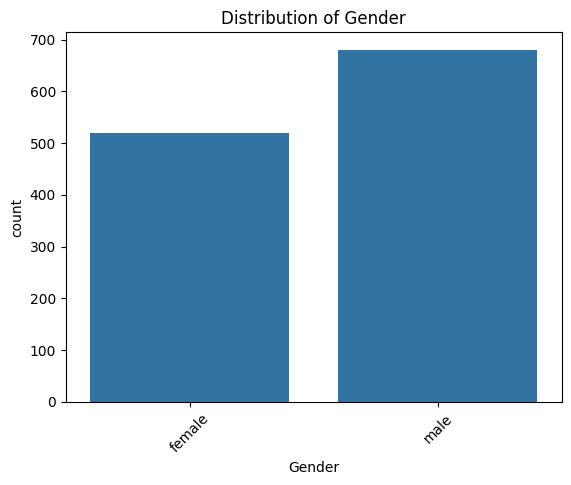

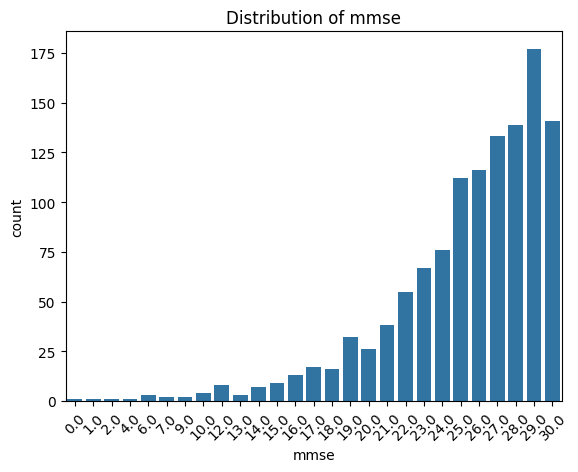

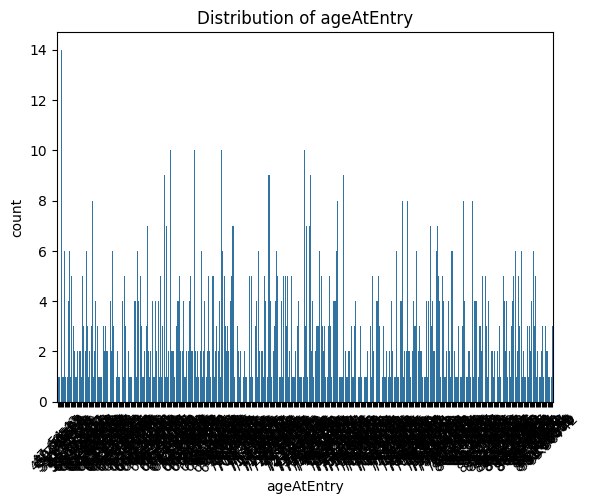

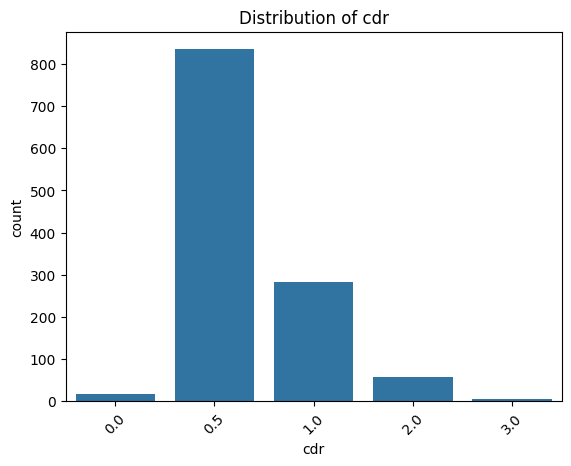

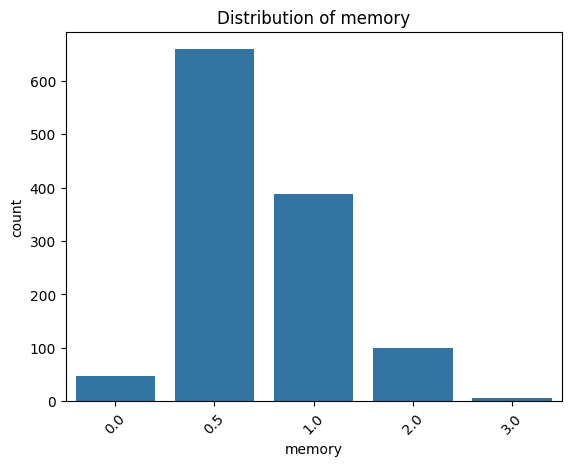

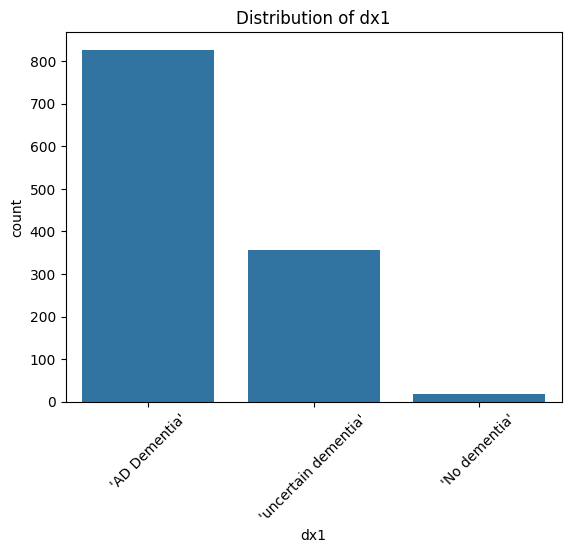

In [38]:
# Show all distributions of the columns 
for col in ['Gender', 'mmse', 'ageAtEntry', 'cdr', 'memory', 'dx1']:
  plt.figure()
  sns.countplot(data=df1, x=col)
  plt.title(f'Distribution of {col}')
  plt.xticks(rotation=45)
  plt.show()

In [67]:
# Assign features 
features = df1.select_dtypes(include=['int', 'float']).columns.tolist()
features

['mmse', 'ageAtEntry', 'cdr', 'memory']

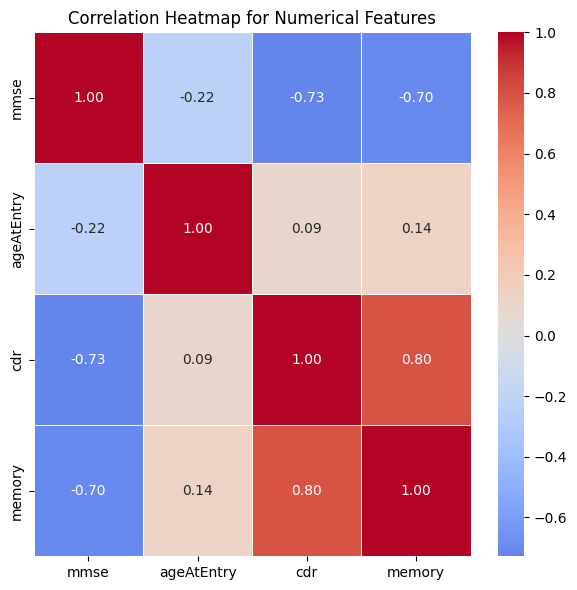

In [68]:
# Calculate correlation matrix
corr_matrix = df1[features].corr()

# Correlation heatmap for numerical features
# Plot heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap for Numerical Features')
plt.tight_layout()
plt.show()

### Interpretation for the correlation results:
- *cdr* & *memory*: r=0.80 -> strong positive correlation.
- *cdr* & *mmse*: r=-0.73 -> strong negative correlation.
- *mmse* & *memory*: r=-0.70 -> strong negative correlation.
- *ageAtEntry* has only weak correlations with the clinical variables.

*=>* *cdr, mmse, and memory are largely describing the same underlying cognitive/disease-severity signal.*

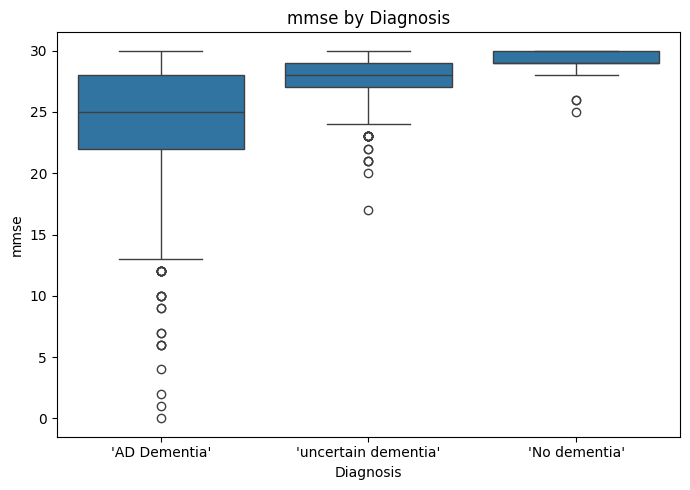

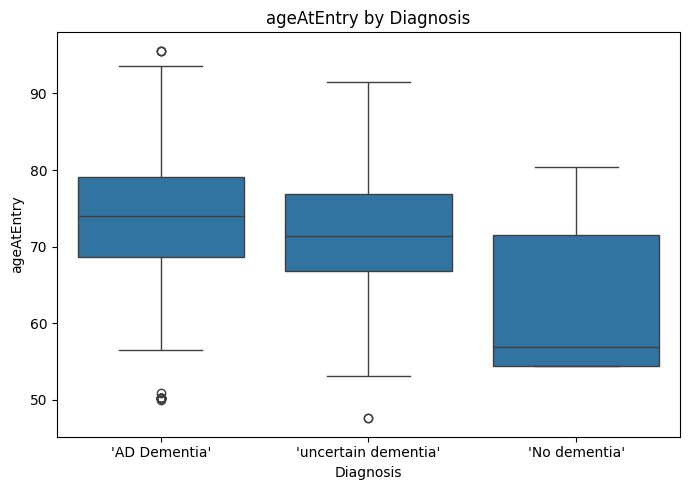

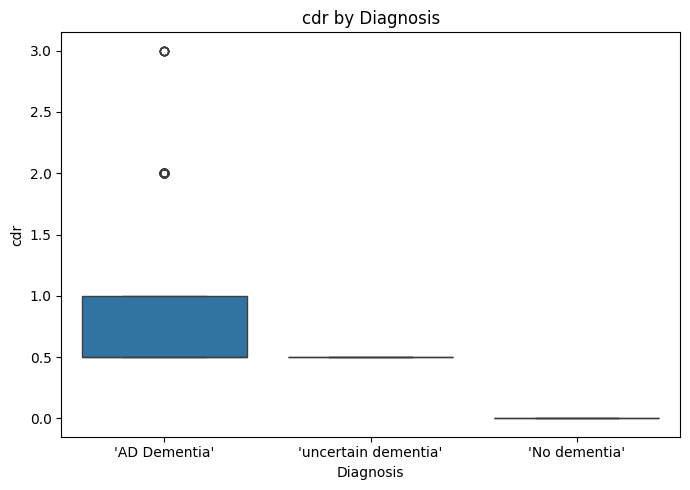

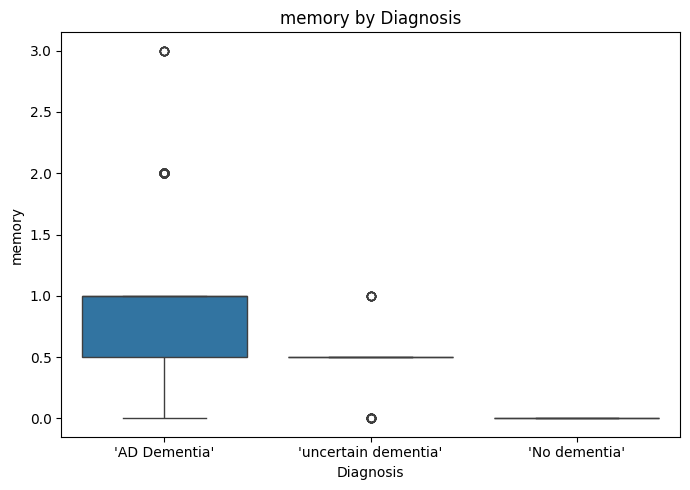

In [69]:
# Checking data leakage
for features in features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df1,
        x='dx1',
        y=features
    )

    plt.title(f'{features} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(features)

    plt.tight_layout()
    plt.show()

3. ML Models

In [73]:
# Convert Gender column as binary values
# Assign 0 is male and female is 1
df1['Gender'] = df1['Gender'].apply(lambda x: 0 if x == 'male' else 1) 

In [115]:
# Features X:
X = df1[['Gender', 'mmse', 'ageAtEntry', 'cdr', 'memory']]

# Target y:
y = df1['dx1']

print('Feature Columns:')
print(X.columns,'\n')
print('Diagnosis:')
print(y.value_counts())

Feature Columns:
Index(['Gender', 'mmse', 'ageAtEntry', 'cdr', 'memory'], dtype='object') 

Diagnosis:
dx1
'AD Dementia'           827
'uncertain dementia'    356
'No dementia'            17
Name: count, dtype: int64


In [116]:
from sklearn.model_selection import train_test_split

# =====================================================
# 1. CLEAN SUBJECT IDs
# =====================================================
df1['Subject'] = df1['Subject'].astype(str).str.strip()

# =====================================================
# 2. GET UNIQUE SUBJECTS
# =====================================================
unique_subjects = df1['Subject'].unique()

print("Total rows:", len(df1))
print("Unique subjects:", len(unique_subjects))


# =====================================================
# 3. SPLIT SUBJECTS, NOT ROWS
# =====================================================
train_subjects, test_subjects = train_test_split(
    unique_subjects,
    test_size=0.20,
    random_state=42
)


# =====================================================
# 4. CREATE TRAIN / TEST DATAFRAMES
# =====================================================
train_df1 = df1[df1['Subject'].isin(train_subjects)].copy()
test_df1  = df1[df1['Subject'].isin(test_subjects)].copy()


# =====================================================
# 5. VERIFY
# =====================================================
overlap = set(train_df1['Subject']).intersection(
    set(test_df1['Subject'])
)

print("Overlap:", overlap)
print("Number of overlapping subjects:", len(overlap))

Total rows: 1200
Unique subjects: 424
Overlap: set()
Number of overlapping subjects: 0


#### Final Conclusion:
- This notebook work is for practicing EDA.
- Cannot use this dataset for model training due to heavily imbalanced data.